In [7]:
"""Redoing some plots for poster in order to make them nice, pretty, and readable"""

'Redoing some plots for poster in order to make them nice, pretty, and readable'

In [23]:
"""Imports"""
import os
import pickle
import traceback
import numpy as np
import uproot
import time
import matplotlib.pyplot as plt
from timing_corrections import RELEVANT_CHANNELS
import matplotlib.cm as cm
import numpy as np
from matplotlib.patches import Patch

In [9]:
"""Constants"""
IRRELEVANT_CHANNELS = [
    "adc_b1_ch0",
    "adc_b2_ch15",
    "adc_b4_ch12",
    "adc_b4_ch13",
    "adc_b4_ch14",
    "adc_b4_ch15",
    "adc_b5_ch0",
    "adc_b5_ch33",
    "adc_b5_ch34",
    "adc_b5_ch35",
    "adc_b5_ch39",
]

In [10]:
"""Copying functions from format_for_NN_more_tagging"""
def get_1t_info(fname: str):
    f = uproot.open(fname)
    daq = f["daq"]
    # sometimes this isn't in the root file
    if "run_info" in f:
        run_info = f["run_info"]
    else:
        run_info = None
    daqkeys = daq.keys()
    traces = {}
    for key in daq.keys():
        if "adc" in key:
            traces[key] = daq[key].array(library="np")
    event_ttt1 = daq["event_ttt_1"].array(library="np")
    event_ttt2 = daq["event_ttt_2"].array(library="np")
    event_ttt3 = daq["event_ttt_3"].array(library="np")
    event_ttt4 = daq["event_ttt_4"].array(library="np")
    event_ttt5 = daq["event_ttt_5"].array(library="np")
    event_id = daq["event_id"].array(library="np")
    event_sanity = daq["event_sanity"].array(library="np")
    # event_ttt = daq['event_ttt'].array(library='np')

    return (
        traces,
        event_ttt1.astype(np.int64),
        event_ttt2.astype(np.int64),
        event_ttt3.astype(np.int64),
        event_ttt4.astype(np.int64),
        event_ttt5.astype(np.int64),
        event_id,
        event_sanity,
        daqkeys,
        run_info,
    )


def need_event_mismatch_correction(fname: str):
    """This function breaks at year 2100. But so does this file convention naming anyways."""
    temp1 = fname.split("/")[-1]  # gets the actual fname from the path
    temp2 = temp1.split("_")
    date_string = temp2[2][:6]
    if 241017 <= int(date_string) <= 250329:
        print("event mismatch will be done for " + fname)
        return True
    return False


def write_corrected_root(
    outfname,
    traces,
    event_ttt1,
    event_ttt2,
    event_ttt3,
    event_ttt4,
    event_ttt5,
    event_id,
    event_sanity,
    daqkeys,
    run_info,
    event_ttt1_good_final,
    event_ttt5_good_final,
):

    new_daq = {}
    for key in daqkeys:
        if "adc_b5" in key:
            new_daq[key] = traces[key][event_ttt5_good_final]
        elif "adc" in key:
            new_daq[key] = traces[key][event_ttt1_good_final]
    new_daq["event_ttt_5"] = event_ttt5[event_ttt5_good_final]
    new_daq["event_ttt_4"] = event_ttt4[event_ttt1_good_final]
    new_daq["event_ttt_3"] = event_ttt3[event_ttt1_good_final]
    new_daq["event_ttt_2"] = event_ttt2[event_ttt1_good_final]
    new_daq["event_ttt_1"] = event_ttt1[event_ttt1_good_final]
    new_daq["event_id"] = event_id[event_ttt1_good_final]
    new_daq["event_sanity"] = event_sanity[event_ttt1_good_final]

    output_file = uproot.recreate(outfname)
    output_file["daq"] = {branch: new_daq[branch] for branch in new_daq}

    if run_info is not None:
        data = run_info.arrays(library="np")
        output_file["run_info"] = {branch: data[branch] for branch in data}
    output_file.close()


def correct_times(event_ttt1, event_ttt5, event_id):
    """Correct the events by comparing closest in 1 and 5 board"""
    array_idx = sorted(range(len(event_id)), key=lambda i: event_id[i])

    event_ttt5_good = event_ttt5[array_idx]
    event_ttt1_good = event_ttt1[array_idx]

    event_ttt5_good_idx = []
    event_ttt1_good_idx = []

    window_size = 3

    for i, val1 in enumerate(event_ttt1_good):
        # Define the search window (max 3 elements before and after in event_ttt5_good)
        start_idx = max(i - window_size, 0)
        end_idx = min(i + window_size + 1, len(event_ttt5_good))

        # Find the index of the closest element in event_ttt5_good within the window
        local_window = event_ttt5_good[start_idx:end_idx]
        closest_idx = (
            np.argmin(np.abs(local_window - val1)) + start_idx
        )  # Add start_idx to get global index

        if -17 < (event_ttt5_good[closest_idx] - val1) < -13:
            event_ttt1_good_idx.append(i)
            event_ttt5_good_idx.append(closest_idx)

    event_ttt1_good_final = np.array(array_idx)[event_ttt1_good_idx]
    event_ttt5_good_final = np.array(array_idx)[event_ttt5_good_idx]

    return event_ttt1_good_final, event_ttt5_good_final


def quickly_correct_file(fname: str, outfname: str) -> str:
    """Does only event mismatch correction, and only if needed."""
    if not need_event_mismatch_correction(fname):
        return fname
    (
        file_traces,
        event_ttt1,
        event_ttt2,
        event_ttt3,
        event_ttt4,
        event_ttt5,
        file_event_ids,
        file_event_sanity,
        file_daqkeys,
        file_run_info,
    ) = get_1t_info(fname)
    mismatch_corrected_event_ttt1, mismatch_corrected_event_ttt5 = correct_times(
        event_ttt1, event_ttt5, file_event_ids
    )
    write_corrected_root(
        outfname,
        file_traces,
        event_ttt1,
        event_ttt2,
        event_ttt3,
        event_ttt4,
        event_ttt5,
        file_event_ids,
        file_event_sanity,
        file_daqkeys,
        file_run_info,
        mismatch_corrected_event_ttt1,
        mismatch_corrected_event_ttt5,
    )
    print("ROOT file corrected for " + fname)
    return outfname


def base_and_flip(waveform):
    """Subtract baseline and reflect over x axis"""
    positive_waveform = (waveform - np.median(waveform)) * (-1)
    return positive_waveform


def nn_is_dumb(hitnet_inp, all_chargenet_inp, per_chargenet_inp):
    """Silly NN is a mere computer and thinks all hit times should begin at 60ns. Take the
    min PMT hit time and shift it to 60, shift everything else by that same factor as well.
    However, early dark counts could interfere. So, find median hit time and look behind 20ns
    and forward 20 ns (40ns window, found from plot of summed waveform cumsum)"""
    # print("init hitnet[3]", hitnet_inp[3])
    median_hit_time = np.median(hitnet_inp[3])
    min_hit_time = median_hit_time - 20
    max_hit_time = median_hit_time + 20
    remove_these = [
        i
        for i in range(len(hitnet_inp[3]))
        if (hitnet_inp[3][i] < min_hit_time) or (hitnet_inp[3][i] > max_hit_time)
    ]
    # print(remove_these)
    # first make the easy changes to all_chargenet_inp and per_chargenet_inp
    for idx in sorted(remove_these, reverse=True):
        per_chargenet_inp[3][idx] = 0
        del all_chargenet_inp[0][idx]  # delete dark hit charge
    all_chargenet_inp[0] = np.sum(all_chargenet_inp[0])  # reformulate as sum
    all_chargenet_inp[1] -= len(remove_these)  # subtract dark hits

    # now change hitnet_inp
    for idx in sorted(remove_these, reverse=True):
        for sublist in hitnet_inp:
            del sublist[idx]  # delete every entry for dark count

        # for sublist in per_chargenet_inp:  # same for this too
        #     del sublist[idx]

    # print("final hitnet[3]", hitnet_inp[3])
    hit_time_shift = 60 - min(hitnet_inp[3])
    hitnet_inp[3] = [hit_time + hit_time_shift for hit_time in hitnet_inp[3]]
    print("post nn_is_dum all chargenet inp", all_chargenet_inp)
    return hitnet_inp, all_chargenet_inp, per_chargenet_inp


def weighted_average_hit_time(waveform, window_size=10):
    """Do weighted average in window around pulse. Returns float value at which
    hit time occurred in ns (multiply by 2 at end, 500MHz)"""
    # Call correction algorithm
    waveform = base_and_flip(waveform)

    # Make into list
    waveform = list(waveform)

    # Find index of max (the pulse peak)
    peak_index = waveform.index(max(waveform))

    # Define window bounds
    half_window = window_size // 2
    start = max(0, peak_index - half_window)
    end = min(len(waveform), peak_index + half_window + 1)

    # Get time (index) and amplitude (value) in the window
    times = list(range(start, end))
    amplitudes = waveform[start:end]

    # Compute weighted average hit time
    numerator = sum(t * a for t, a in zip(times, amplitudes))
    denominator = sum(amplitudes)

    if denominator == 0:
        return None  # Avoid divide-by-zero
    # accounts for the fact that we are technically returning the sample index of the peak. since
    # sampling rate is 500MHz, we multiply by 2 to get ns
    return (numerator / denominator) * 2


def constant_fraction_time(waveform, fraction=0.5, time_step=1.0):
    """Do leading edge CFD to find when pulse height is 50% of maximum."""
    waveform = np.array(base_and_flip(waveform))
    max_val = np.max(waveform)
    threshold = fraction * max_val

    # Find where signal crosses threshold
    for i in range(1, len(waveform)):
        if waveform[i - 1] < threshold <= waveform[i]:
            # linear interpolation to estimate crossing time
            t0 = (i - 1) * time_step
            y0 = waveform[i - 1]
            y1 = waveform[i]
            crossing_time = t0 + time_step * (threshold - y0) / (y1 - y0)
            return crossing_time
    return None  # no crossing found


def get_channel_charge(waveform):
    """Takes in a raw waveform. Does baseline subtraction, makes it positive, make window of
    size 10, integrate, divide by 50 (resistance),
    returns charge in pC"""
    based_flipped = base_and_flip(waveform) * voltageFactor
    time_of_max = np.argmax(based_flipped)
    charge_pC = np.sum(based_flipped[time_of_max - 5 : time_of_max + 5]) * 2 / 50 # 10 points, 2ns dt, 50ohms
    return charge_pC


def waveform_daisy_correction(waveform, boardID):
    if (boardID < 1) or (boardID > 5):
        print("Bad BoardID")
        return False
    elif boardID == 5:
        return waveform
    elif boardID != 1:
        return waveform[24 * (4 - boardID) : -24 * (boardID - 1)]
    else:
        return waveform[24 * 3 :]


def is_pulse(waveform: np.ndarray, range_min: int = 0, range_max: int = 1928) -> bool:
    """Takes in a daisy corrected waveform and looks in a given range to see if there is a pulse.
    For example, you can use some range around an alpha PMT hit if looking for just alpha detections.
    Uses charge to determine if the pulse exceeds threshold or is just noise / fluctuations
    """
    wave_cut = waveform[range_min:range_max]
    if get_channel_charge(wave_cut) >= 2:
        return True
    return False


def b1_ch0_or_b2_ch15_detections(traces):
    """These are bottom paddle channels, gets list of events with detections."""
    b1_ch0_only_list = []
    b2_ch15_only_list = []

    b1_ch0_waveforms_list = traces["adc_b1_ch0"]
    b2_ch15_waveforms_list = traces["adc_b2_ch15"]
    for i, waveform in enumerate(b1_ch0_waveforms_list):
        if is_pulse(waveform):  # this is arbitrary, and hopefully this is sufficient
            b1_ch0_only_list.append(i)
    for i, waveform in enumerate(b2_ch15_waveforms_list):
        if is_pulse(waveform):  # this is arbitrary, and hopefully this is sufficient
            b2_ch15_only_list.append(i)
    return b1_ch0_only_list, b2_ch15_only_list


def b4_ch13_or_ch14_detections(traces):
    """These are top paddle channels, gets list of events with detections."""
    b4_ch13_or_ch14_detection_list = []
    waveforms_list = traces["adc_b4_ch13"] + traces["adc_b4_ch14"]
    for i, waveform in enumerate(waveforms_list):
        if is_pulse(waveform):  # this is arbitrary, and hopefully this is sufficient
            b4_ch13_or_ch14_detection_list.append(i)
    return b4_ch13_or_ch14_detection_list  # could hit both top paddles


def top_paddle_event_list(traces) -> list[int]:
    """Returns a list of event indices that correspond to top_paddle trigger events.
    This means b4_ch13 OR b4_ch14 has a signal AND that the superposition of signals
    for that event lies in the time range for top_paddle events."""

    twice_checked_top_paddle_event_index_list = []
    num_events = len(traces["adc_b2_ch1"])  # pick arbitrary PMT, all same length
    top_paddle_PMT_events = b4_ch13_or_ch14_detections(traces)  # fix for top_paddle

    for i in range(num_events):
        corrected_waveforms_per_event = []
        # waveform loop to get the i_th waveform for each PMT
        for key in traces.keys():
            if ("b5" in key) or (key in IRRELEVANT_CHANNELS):  # Adam said disregard
                continue
            board_num = int(key[5])
            uncorrected_waveform = traces[key][i]

            corrected_waveforms_per_event.append(
                waveform_daisy_correction(uncorrected_waveform, board_num)
            )
        summed_waveform = np.sum(corrected_waveforms_per_event, axis=0)
        # using argmin here should be fine, we don't need anything too accurate
        peak_sample_time_ns = np.argmin(summed_waveform) * 2  # converts to ns
        # rough estimate of time range
        if 750 < peak_sample_time_ns and i in top_paddle_PMT_events:
            twice_checked_top_paddle_event_index_list.append(i)
    return twice_checked_top_paddle_event_index_list


def b4_ch12_detections(traces) -> list[int]:
    """Returns a list of the event indices where the alpha PMT goes off. The waveform is not altered at all prior to this.
    In other words, we are purely looking at the shape of the waveform."""
    b4_ch12_detection_list = []
    waveforms_list = traces["adc_b4_ch12"]
    for i, waveform in enumerate(waveforms_list):
        if is_pulse(waveform):  # this is arbitrary, and hopefully this is sufficient
            b4_ch12_detection_list.append(i)
    return b4_ch12_detection_list


def alpha_event_list(traces) -> list[int]:
    """Returns a list of event indices that correspond to alpha particle events.
    This means b4_ch12 has a signal and the superposition of signals for that event
    lies in the time range for alpha events."""

    twice_checked_alpha_event_index_list = []
    num_events = len(traces["adc_b2_ch1"])  # pick arbitrary PMT, all same length
    alpha_PMT_events = b4_ch12_detections(traces)

    for i in range(num_events):
        corrected_waveforms_per_event = []
        # waveform loop to get the i_th waveform for each PMT
        for key in traces.keys():
            if ("b5" in key) or (key in IRRELEVANT_CHANNELS):  # Adam said disregard
                continue
            board_num = int(key[5])
            uncorrected_waveform = traces[key][i]
            corrected_waveforms_per_event.append(
                waveform_daisy_correction(uncorrected_waveform, board_num)
            )
        summed_waveform = np.sum(corrected_waveforms_per_event, axis=0)
        peak_sample_time_ns = np.argmin(summed_waveform) * 2
        # rough estimate of time range
        if 550 < peak_sample_time_ns < 750 and i in alpha_PMT_events:
            twice_checked_alpha_event_index_list.append(i)
    return twice_checked_alpha_event_index_list


def get_all_sensor_input(fname: str, peak_method: str):
    """Takes in a file path and a peak_method, which is either CFD or weighted avg.
    Then the information for all-sensor chargenet AND all-sensor hitnet is returned.
    "all" refers to all-sensor and "per" refers to per-sensor. I tried to remember to
    use "total" when talking about everything and "all" when referring to sensor type.
    Now added per-sensor.
    """

    all_events = []
    per_events = []
    event_tagging_list = []

    traces = get_1t_info(fname)[0]

    alpha_events = alpha_event_list(traces)
    num_events = len(traces["adc_b2_ch1"])  # pick arbitrary PMT, all same length

    for i in range(num_events):

        # Skip over all alpha events, these are irrelevant ones
        if i in alpha_events:
            continue

        # instantiate some network variables
        hitnet_input = [[], [], [], [], []]
        all_chargenet_input = []
        per_chargenet_input = [[], [], [], []]
        temp_chargenet = []
        num_of_hits = 0

        event_tagging_dict = {"TP": [], "TP_supp": [], "hodo": [], "BP": []}

        # waveform loop to get the i_th waveform for each PMT
        for key in traces.keys():

            # get only necessary info to do tagging
            uncorrected_waveform = traces[key][i]
            board_num = int(key[5])
            # perform daisy correction and change to ns (500MHz sampling)
            daisy_corrected_waveform = waveform_daisy_correction(
                uncorrected_waveform, board_num
            )
            waveform_charge = get_channel_charge(daisy_corrected_waveform)

            # do tagging
            if waveform_charge >= 2:
                # print(waveform_charge, "for key", key)
                if key in TP_PMTs:
                    event_tagging_dict["TP"].append(key)
                elif key in TP_supp_PMTs:
                    event_tagging_dict["TP_supp"].append(key)
                elif key in HODOSCOPE_PMTs:
                    event_tagging_dict["hodo"].append(key)
                elif key in BP_PMTs:
                    event_tagging_dict["BP"].append(key)

            # continue, we only want the 58 PMTs added to network
            if ("b5" in key) or (key in IRRELEVANT_CHANNELS):
                continue

            # skip if not a pulse
            # restricting the window could help, but really that's the job of the twice
            # checked TP events function. make sure superposition is proper
            # if not is_pulse(daisy_corrected_waveform): #range_min=750):
            #     continue

            # gets waveform charge and checks if it's a pulse. also add to per_chargenet
            # here since we need everything regardless of if pulse or not

            per_chargenet_input[0].append(PMT_location_dict[key][0])
            per_chargenet_input[1].append(PMT_location_dict[key][1])
            per_chargenet_input[2].append(PMT_location_dict[key][2])
            if waveform_charge < 2:  # this is equivalent to is_pulse
                # assume this is dark count and zero, so any charge not due to muon
                per_chargenet_input[3].append(0)
                continue
            # print("hit for", key)

            # add to chargenet
            per_chargenet_input[3].append(waveform_charge)

            # find peak time
            if peak_method == "cfd":
                peak_method_hit_time = constant_fraction_time(
                    daisy_corrected_waveform, fraction=0.5, time_step=2
                )
            elif peak_method == "weight":
                peak_method_hit_time = weighted_average_hit_time(
                    daisy_corrected_waveform
                )
            if peak_method_hit_time is None:
                continue  # if peak method fails, continue
            pmt_hit_time = peak_method_hit_time - PMT_channel_delay_dict[key]

            # hitnet input consecutively so that everything is same size
            hitnet_input[0].append(PMT_location_dict[key][0])
            hitnet_input[1].append(PMT_location_dict[key][1])
            hitnet_input[2].append(PMT_location_dict[key][2])
            hitnet_input[3].append(pmt_hit_time)
            hitnet_input[4].append(1)

            # chargenet values to later input
            temp_chargenet.append(waveform_charge)
            # sum_of_charges_of_all_hits += waveform_charge
            num_of_hits += 1

        # Check if we have any hits AND check if charge is reasonable
        # only append if there's anything to reco
        # also, we need hits greater than 3 because firstly there isn't much to reco with 2
        # hits and secondly the median of 2 values is an in between, and so the "not dark count" window
        # fails in the nn_is_dumb function (min() of empty list)
        if num_of_hits < 3:
            continue  # to next event

        # if sum(event_tagging_dict.values(), []) == []: # could use truthy falsey to be cool
        #     continue # we don't want events without ANY tagging...

        if len(event_tagging_dict["hodo"]) < 2:
            continue
        print(event_tagging_dict)
        # chargenet input
        all_chargenet_input.append(temp_chargenet)
        all_chargenet_input.append(num_of_hits)
        try:
            # reassign to please the picky NN
            hitnet_input, all_chargenet_input, per_chargenet_input = nn_is_dumb(
                hitnet_input, all_chargenet_input, per_chargenet_input
            )
            # if total charge is greater than 5800pC, meaning that on average each PMT had
            # 100pC signal, just skip the whole event. Be conservative for best statistics
            if all_chargenet_input[0] > 10_000:
                print("skipped, too high charge")
                continue
            # print("min hit time", min(hitnet_input[3]))  ###
            all_event = {
                "hits": np.stack(hitnet_input, axis=1),
                "total_charge": np.stack(all_chargenet_input),
            }
            per_event = {
                "hits": np.stack(hitnet_input, axis=1),
                "total_charge": np.stack(per_chargenet_input, axis=1),
            }
            # At this point, we have formatted everything properly for NN
            all_events.append(all_event)
            per_events.append(per_event)
            event_tagging_list.append(event_tagging_dict)
        except ValueError as e:
            # sometimes due to so few hits, all hit times are seen as dark counts. just
            # skip these
            if str(e) == "min() arg is an empty sequence":
                print(f"Skipped {i} due to empty sequence error.")

    return all_events, per_events, event_tagging_list

In [11]:
superposition_times = []

phase_directory = "/media/disk_d/WbLS-DATA/raw_root/phase3/muon/"  # Oct 31, 2024
# phase_directory = "/media/disk_o/my_corrected_roots/disk_d_phase3/"  # corrected
# phase_directory = "/media/disk_e/WbLS-DATA/raw_root/phase3/muon/"  # Nov 13, 2024
# phase_directory = "/media/disk_a/WbLS-DATA/raw_root/phase6/muon/" # Jan 07, 2025
# phase_directory = "/media/disk_b/WbLS-DATA/raw_root/phase5/muon/" # Dec 12, 2024
# phase_directory = "/media/disk_b/WbLS-DATA/raw_root/phase6/muon/" # Dec 19, 2024
# phase_directory = "/media/disk_e/WbLS-DATA/raw_root/phase4/muon/" # Dec 03, 2024
# phase_directory = "/media/disk_k/WbLS-DATA/raw_root/phase8/muon/" # Mar 11, 2025
# phase_directory = "/media/disk_l/WbLS-DATA/raw_root/phase9/muon/"  # Mar 27, 2025
file_paths_in_phase = [
    phase_directory + str(f)
    for f in os.listdir(phase_directory)
    if os.path.isfile(os.path.join(phase_directory, f))
][:10]
print("num of files", len(file_paths_in_phase))

for f in file_paths_in_phase:
    if "water" not in f: continue
    print("doing", f)
    try:
        traces = get_1t_info(f)[0]
        num_events = len(traces["adc_b2_ch1"])  # pick arbitrary PMT, all same length

        for i in range(num_events):
            corrected_waveforms_per_event = []
            # waveform loop to get the i_th waveform for each PMT
            for key in traces.keys():
                if ("b5" in key) or (key in IRRELEVANT_CHANNELS):  # Adam said disregard
                    continue
                board_num = int(key[5])
                uncorrected_waveform = traces[key][i]
                corrected_waveforms_per_event.append(
                    waveform_daisy_correction(uncorrected_waveform, board_num)
                )
            summed_waveform = np.sum(corrected_waveforms_per_event, axis=0)
            peak_sample_time_ns = np.argmin(summed_waveform) * 2 # 500MHz
            superposition_times.append(peak_sample_time_ns)
    except Exception as e:
        print(f"Skipped {f} due to error: {e}")
        traceback.print_exc()

num of files 10
doing /media/disk_d/WbLS-DATA/raw_root/phase3/muon/muon_water_241106T0956_14.root
doing /media/disk_d/WbLS-DATA/raw_root/phase3/muon/muon_water_241107T1323_53.root
doing /media/disk_d/WbLS-DATA/raw_root/phase3/muon/muon_water_241112T0917_28.root
doing /media/disk_d/WbLS-DATA/raw_root/phase3/muon/muon_water_241028T0921_95.root
doing /media/disk_d/WbLS-DATA/raw_root/phase3/muon/muon_water_241104T1700_4.root
doing /media/disk_d/WbLS-DATA/raw_root/phase3/muon/muon_water_241108T1022_10.root
doing /media/disk_d/WbLS-DATA/raw_root/phase3/muon/muon_water_241029T1143_57.root
doing /media/disk_d/WbLS-DATA/raw_root/phase3/muon/muon_water_241103T0742_57.root


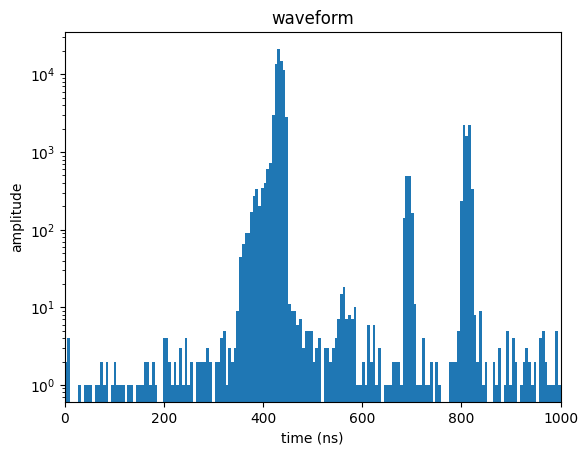

In [12]:
plt.hist(superposition_times, bins=700)
# Add labels and title
plt.xlabel("time (ns)")
plt.ylabel("amplitude")
plt.title("waveform")

# plt.xlim(350,850)
plt.xlim(0,1000)
plt.yscale("log")
# Show the plot
plt.show()
plt.close()

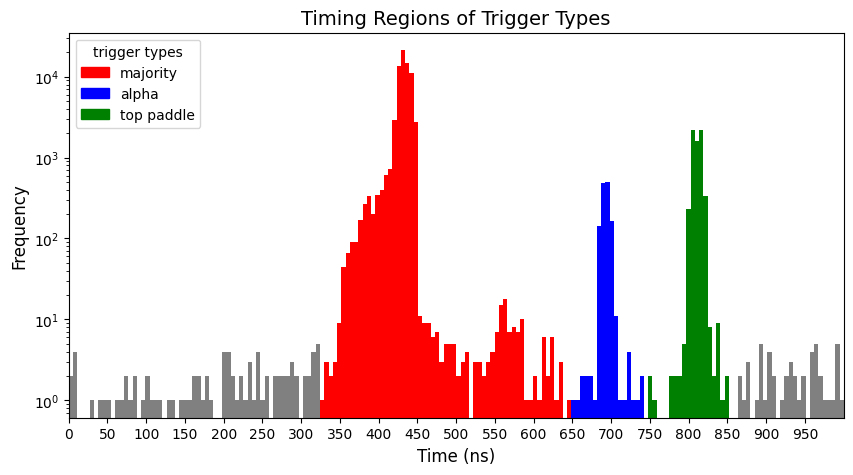

In [32]:
# Your data and histogram
counts, bins = np.histogram(superposition_times, bins=700)

# Compute bin centers for plotting
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = bins[1] - bins[0]

# Define a color function based on x position
colors = []
for x in bin_centers:
    if 325 < x < 650:
        colors.append("red")
    elif 650 <= x < 750:
        colors.append("blue")
    elif 750 <= x < 850:
        colors.append("green")
    else:
        colors.append("gray")

# Plot using plt.bar
plt.figure(figsize=(10, 5))
plt.bar(bin_centers, counts, width=bin_width, color=colors, log=True)

# Labels and axis
plt.xlabel("Time (ns)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Timing Regions of Trigger Types", fontsize=14)
plt.xlim(0, 1000)
plt.xticks([x for x in range(0, 1000, 50)])
legend_patches = [
    Patch(color="red", label="majority"),
    Patch(color="blue", label="alpha"),
    Patch(color="green", label="top paddle")
]
plt.legend(handles=legend_patches, title="trigger types", loc="upper left")

# plt.show()
# plt.close()
plt.savefig("/media/disk_o/my_plot_pngs/trigger_types.png", dpi=300)


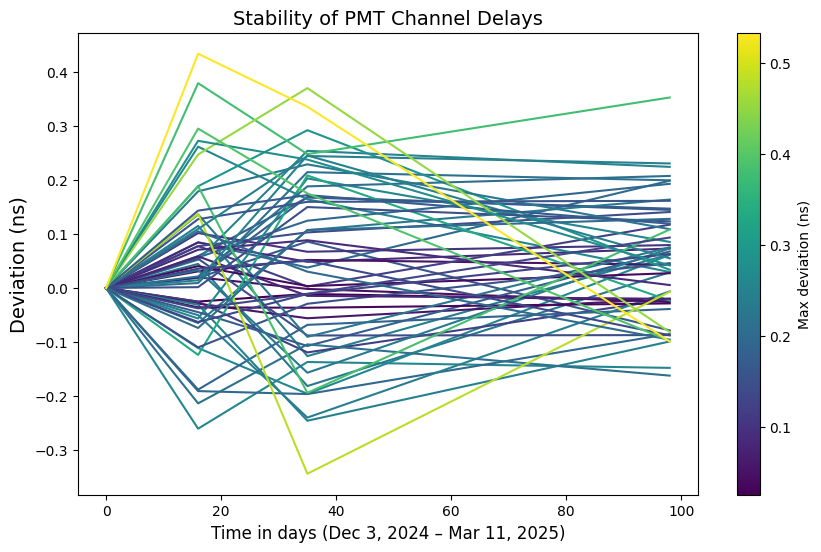

In [14]:
disk_e_phase_4 = {'adc_b1_ch1': np.float64(1.225671252992048), 'adc_b1_ch2': np.float64(3.894440254440198), 'adc_b1_ch3': np.float64(4.87956085682908), 'adc_b1_ch4': np.float64(0.7731792434802589), 'adc_b1_ch5': np.float64(4.659396581658646), 'adc_b1_ch6': np.float64(4.829461885696852), 'adc_b1_ch7': np.float64(3.3343953170856593), 'adc_b1_ch8': np.float64(2.7792263735699083), 'adc_b1_ch9': np.float64(3.5828309142214394), 'adc_b1_ch10': np.float64(4.185319446438333), 'adc_b1_ch11': np.float64(5.045944368633656), 'adc_b1_ch12': np.float64(2.6965648887072713), 'adc_b1_ch13': np.float64(2.5884521301262278), 'adc_b1_ch14': np.float64(3.564158620899183), 'adc_b1_ch15': np.float64(4.233119200773835), 'adc_b2_ch0': np.float64(5.0207734054640785), 'adc_b2_ch1': np.float64(3.4888693187238666), 'adc_b2_ch2': np.float64(3.8060054656480107), 'adc_b2_ch3': np.float64(3.053823737032424), 'adc_b2_ch4': np.float64(1.909448753093475), 'adc_b2_ch5': np.float64(2.649524474995857), 'adc_b2_ch6': np.float64(6.115986520104239), 'adc_b2_ch7': np.float64(4.281382211075034), 'adc_b2_ch8': np.float64(0.7625514177844037), 'adc_b2_ch9': np.float64(4.021728891149163), 'adc_b2_ch10': np.float64(4.87623458518239), 'adc_b2_ch11': np.float64(4.455794018001793), 'adc_b2_ch12': np.float64(3.2326281817138574), 'adc_b2_ch13': np.float64(3.7389536905239713), 'adc_b2_ch14': np.float64(2.3552405573600836), 'adc_b3_ch0': np.float64(3.740841815360168), 'adc_b3_ch1': np.float64(1.8818837546166343), 'adc_b3_ch2': np.float64(4.246946895345981), 'adc_b3_ch3': np.float64(6.983357505607806), 'adc_b3_ch4': np.float64(1.3777546253461788), 'adc_b3_ch5': np.float64(2.1773656087268005), 'adc_b3_ch6': np.float64(4.639030524674204), 'adc_b3_ch7': np.float64(3.630461362665645), 'adc_b3_ch8': np.float64(3.1251646518888587), 'adc_b3_ch9': np.float64(5.1032274388567656), 'adc_b3_ch10': np.float64(2.935855088139991), 'adc_b3_ch11': np.float64(4.007466328334388), 'adc_b3_ch12': np.float64(2.636031471246141), 'adc_b3_ch13': np.float64(3.6147086351542304), 'adc_b3_ch14': np.float64(4.083015580583016), 'adc_b3_ch15': np.float64(1.4542877527095794), 'adc_b4_ch0': np.float64(3.524310085890582), 'adc_b4_ch1': np.float64(2.964410326643317), 'adc_b4_ch2': np.float64(5.515985389605042), 'adc_b4_ch3': np.float64(4.329758780805552), 'adc_b4_ch4': np.float64(2.828791812528712), 'adc_b4_ch5': np.float64(2.5501018399069943), 'adc_b4_ch6': np.float64(3.3433102450091434), 'adc_b4_ch7': np.float64(4.669658168870571), 'adc_b4_ch8': np.float64(10.992174422457682), 'adc_b4_ch9': np.float64(3.14407310457433), 'adc_b4_ch10': np.float64(4.424381958303696), 'adc_b4_ch11': np.float64(4.665626463363248)}
disk_b_phase_6 = {'adc_b1_ch1': np.float64(0.9648248931714862), 'adc_b1_ch2': np.float64(3.939005155846118), 'adc_b1_ch3': np.float64(4.994590240830412), 'adc_b1_ch4': np.float64(0.6618321005589411), 'adc_b1_ch5': np.float64(4.634171725789534), 'adc_b1_ch6': np.float64(4.803931216211205), 'adc_b1_ch7': np.float64(3.3533394521104127), 'adc_b1_ch8': np.float64(2.798249486805925), 'adc_b1_ch9': np.float64(3.6674621967533554), 'adc_b1_ch10': np.float64(4.269709059356918), 'adc_b1_ch11': np.float64(5.104967670575007), 'adc_b1_ch12': np.float64(2.508131451876309), 'adc_b1_ch13': np.float64(2.559445185013231), 'adc_b1_ch14': np.float64(3.533115993544276), 'adc_b1_ch15': np.float64(4.49500598394831), 'adc_b2_ch0': np.float64(5.051512216112721), 'adc_b2_ch1': np.float64(3.566242013775034), 'adc_b2_ch2': np.float64(3.8626796814023665), 'adc_b2_ch3': np.float64(3.1314818391842394), 'adc_b2_ch4': np.float64(1.9618393155030596), 'adc_b2_ch5': np.float64(2.5929040200186786), 'adc_b2_ch6': np.float64(5.924792412892383), 'adc_b2_ch7': np.float64(4.230948450051308), 'adc_b2_ch8': np.float64(0.7822664109998199), 'adc_b2_ch9': np.float64(4.123481587421505), 'adc_b2_ch10': np.float64(4.811192496428662), 'adc_b2_ch11': np.float64(4.410952113193357), 'adc_b2_ch12': np.float64(3.196677047333446), 'adc_b2_ch13': np.float64(3.7932712392705246), 'adc_b2_ch14': np.float64(2.3956589037352742), 'adc_b3_ch0': np.float64(3.616707474455209), 'adc_b3_ch1': np.float64(2.018119475765271), 'adc_b3_ch2': np.float64(4.256053982678021), 'adc_b3_ch3': np.float64(6.873195105256308), 'adc_b3_ch4': np.float64(1.5662894934495535), 'adc_b3_ch5': np.float64(1.9634463215604097), 'adc_b3_ch6': np.float64(4.672117857911096), 'adc_b3_ch7': np.float64(3.651735909404184), 'adc_b3_ch8': np.float64(3.5047560325355884), 'adc_b3_ch9': np.float64(5.282306214990103), 'adc_b3_ch10': np.float64(3.0633909492198685), 'adc_b3_ch11': np.float64(4.065973199769658), 'adc_b3_ch12': np.float64(2.7068077072741366), 'adc_b3_ch13': np.float64(3.5515544276128854), 'adc_b3_ch14': np.float64(4.2204463513852275), 'adc_b3_ch15': np.float64(1.6429139397936052), 'adc_b4_ch0': np.float64(3.633611253228415), 'adc_b4_ch1': np.float64(2.9786238806387493), 'adc_b4_ch2': np.float64(5.517463873716245), 'adc_b4_ch3': np.float64(4.2919570320063976), 'adc_b4_ch4': np.float64(2.754608277894411), 'adc_b4_ch5': np.float64(2.693472913421169), 'adc_b4_ch6': np.float64(3.4482547817602773), 'adc_b4_ch7': np.float64(4.7054259245299495), 'adc_b4_ch8': np.float64(11.239571209255958), 'adc_b4_ch9': np.float64(3.4168040753343245), 'adc_b4_ch10': np.float64(4.719781578975029), 'adc_b4_ch11': np.float64(5.099840738921438)}
disk_a_phase_6 = {'adc_b1_ch1': np.float64(1.088425024923855), 'adc_b1_ch2': np.float64(3.712632556617436), 'adc_b1_ch3': np.float64(4.75326127578581), 'adc_b1_ch4': np.float64(0.5769374097665452), 'adc_b1_ch5': np.float64(4.648378477982979), 'adc_b1_ch6': np.float64(4.710007031155961), 'adc_b1_ch7': np.float64(3.4203491187476174), 'adc_b1_ch8': np.float64(2.947967366838238), 'adc_b1_ch9': np.float64(3.620644177388307), 'adc_b1_ch10': np.float64(4.233778707371092), 'adc_b1_ch11': np.float64(5.213592881445749), 'adc_b1_ch12': np.float64(2.6281470014444177), 'adc_b1_ch13': np.float64(2.5323189021525816), 'adc_b1_ch14': np.float64(3.3180561093407497), 'adc_b1_ch15': np.float64(4.397397832013034), 'adc_b2_ch0': np.float64(5.072704031479768), 'adc_b2_ch1': np.float64(3.5918806576639875), 'adc_b2_ch2': np.float64(3.9306737350731256), 'adc_b2_ch3': np.float64(3.056487724475467), 'adc_b2_ch4': np.float64(2.1636390023577725), 'adc_b2_ch5': np.float64(2.852571192686909), 'adc_b2_ch6': np.float64(5.919309994660817), 'adc_b2_ch7': np.float64(4.041107308986064), 'adc_b2_ch8': np.float64(0.7608065352688085), 'adc_b2_ch9': np.float64(4.088838585399568), 'adc_b2_ch10': np.float64(4.983327303808396), 'adc_b2_ch11': np.float64(4.348251027360586), 'adc_b2_ch12': np.float64(3.195913272101529), 'adc_b2_ch13': np.float64(3.650856022370619), 'adc_b2_ch14': np.float64(2.358651593916683), 'adc_b3_ch0': np.float64(3.9493741232967046), 'adc_b3_ch1': np.float64(1.7912704674400821), 'adc_b3_ch2': np.float64(4.4616491247693615), 'adc_b3_ch3': np.float64(6.954063037329625), 'adc_b3_ch4': np.float64(1.6702139131562967), 'adc_b3_ch5': np.float64(2.072827771118737), 'adc_b3_ch6': np.float64(4.481934592420166), 'adc_b3_ch7': np.float64(3.818771278743728), 'adc_b3_ch8': np.float64(3.3732457655939565), 'adc_b3_ch9': np.float64(5.332380650798927), 'adc_b3_ch10': np.float64(3.095494051389099), 'adc_b3_ch11': np.float64(3.992843866360161), 'adc_b3_ch12': np.float64(2.724494831823434), 'adc_b3_ch13': np.float64(3.6035370016808916), 'adc_b3_ch14': np.float64(3.738661596221142), 'adc_b3_ch15': np.float64(1.259896530234276), 'adc_b4_ch0': np.float64(3.7689267517075025), 'adc_b4_ch1': np.float64(3.2100282038578163), 'adc_b4_ch2': np.float64(5.665973135943908), 'adc_b4_ch3': np.float64(4.318700373747053), 'adc_b4_ch4': np.float64(2.936215027272104), 'adc_b4_ch5': np.float64(2.722230117438607), 'adc_b4_ch6': np.float64(3.3735431516503747), 'adc_b4_ch7': np.float64(4.720039658113707), 'adc_b4_ch8': np.float64(11.362634288137459), 'adc_b4_ch9': np.float64(3.382057757566839), 'adc_b4_ch10': np.float64(4.599684900933097), 'adc_b4_ch11': np.float64(5.001738872063806)}
disk_k_phase_8 = {'adc_b1_ch1': np.float64(1.077523983046409), 'adc_b1_ch2': np.float64(3.9235091233367), 'adc_b1_ch3': np.float64(4.941857427553778), 'adc_b1_ch4': np.float64(0.8344392232961315), 'adc_b1_ch5': np.float64(4.636052849411945), 'adc_b1_ch6': np.float64(4.808412417758242), 'adc_b1_ch7': np.float64(3.2557290091384288), 'adc_b1_ch8': np.float64(2.923864891657185), 'adc_b1_ch9': np.float64(3.781646006570817), 'adc_b1_ch10': np.float64(4.258359241462378), 'adc_b1_ch11': np.float64(5.19297357781457), 'adc_b1_ch12': np.float64(2.6575372047100383), 'adc_b1_ch13': np.float64(2.568513779202561), 'adc_b1_ch14': np.float64(3.464959243933412), 'adc_b1_ch15': np.float64(4.262655963114916), 'adc_b2_ch0': np.float64(5.063835567968065), 'adc_b2_ch1': np.float64(3.629643379942659), 'adc_b2_ch2': np.float64(3.999046227169967), 'adc_b2_ch3': np.float64(3.1711764554473874), 'adc_b2_ch4': np.float64(2.1338979634187787), 'adc_b2_ch5': np.float64(2.7348950852809675), 'adc_b2_ch6': np.float64(6.030817493603318), 'adc_b2_ch7': np.float64(4.274967942217138), 'adc_b2_ch8': np.float64(0.7365618674466203), 'adc_b2_ch9': np.float64(4.101207880236753), 'adc_b2_ch10': np.float64(5.040089412277057), 'adc_b2_ch11': np.float64(4.523479804228227), 'adc_b2_ch12': np.float64(3.203989564013477), 'adc_b2_ch13': np.float64(3.651577070953778), 'adc_b2_ch14': np.float64(2.382592614148429), 'adc_b3_ch0': np.float64(3.7175011880808007), 'adc_b3_ch1': np.float64(1.9573401725140194), 'adc_b3_ch2': np.float64(4.446481614323171), 'adc_b3_ch3': np.float64(7.029362818025753), 'adc_b3_ch4': np.float64(1.4114457263225768), 'adc_b3_ch5': np.float64(2.0148729020893352), 'adc_b3_ch6': np.float64(4.712432846991326), 'adc_b3_ch7': np.float64(3.838097699262622), 'adc_b3_ch8': np.float64(3.478217870154786), 'adc_b3_ch9': np.float64(5.2122368528442165), 'adc_b3_ch10': np.float64(3.0973961073726772), 'adc_b3_ch11': np.float64(3.9873572061648734), 'adc_b3_ch12': np.float64(2.6414492807096925), 'adc_b3_ch13': np.float64(3.677676162508718), 'adc_b3_ch14': np.float64(4.075822649805879), 'adc_b3_ch15': np.float64(1.5625795276750734), 'adc_b4_ch0': np.float64(3.755126938635718), 'adc_b4_ch1': np.float64(3.0193250121577213), 'adc_b4_ch2': np.float64(5.639490338875497), 'adc_b4_ch3': np.float64(4.423238728246876), 'adc_b4_ch4': np.float64(2.9568733176428084), 'adc_b4_ch5': np.float64(2.66929003570126), 'adc_b4_ch6': np.float64(3.2475265758205802), 'adc_b4_ch7': np.float64(4.581872543086265), 'adc_b4_ch8': np.float64(10.910299539169076), 'adc_b4_ch9': np.float64(3.18588056472022), 'adc_b4_ch10': np.float64(4.32642516432635), 'adc_b4_ch11': np.float64(4.566400247390499)}


# disk_k_phase_8 = {'adc_b1_ch1': np.float64(7.2789115369563095), 'adc_b1_ch2': np.float64(4.265674901417602), 'adc_b1_ch3': np.float64(5.577876857913603), 'adc_b1_ch4': np.float64(1.4284791180383207), 'adc_b1_ch5': np.float64(5.296731497991809), 'adc_b1_ch6': np.float64(5.340305123402381), 'adc_b1_ch7': np.float64(3.9025018950943133), 'adc_b1_ch8': np.float64(3.3290378656346564), 'adc_b1_ch9': np.float64(3.8822186148534534), 'adc_b1_ch10': np.float64(4.168288706655699), 'adc_b1_ch11': np.float64(5.630742357458182), 'adc_b1_ch12': np.float64(3.176798321389193), 'adc_b1_ch13': np.float64(2.636501478835617), 'adc_b1_ch14': np.float64(3.757620661864749), 'adc_b1_ch15': np.float64(4.631693149051081), 'adc_b2_ch0': np.float64(5.75605868430716), 'adc_b2_ch1': np.float64(4.044198013242846), 'adc_b2_ch2': np.float64(3.99218481804873), 'adc_b2_ch3': np.float64(3.5072277504822256), 'adc_b2_ch4': np.float64(2.4646066520412377), 'adc_b2_ch5': np.float64(3.66884110571994), 'adc_b2_ch6': np.float64(6.0848446058413455), 'adc_b2_ch7': np.float64(4.18533454219572), 'adc_b2_ch8': np.float64(0.6521201336279718), 'adc_b2_ch9': np.float64(4.2890391970978285), 'adc_b2_ch10': np.float64(5.604685697013938), 'adc_b2_ch11': np.float64(4.4578664102193235), 'adc_b2_ch12': np.float64(4.123483970351583), 'adc_b2_ch13': np.float64(4.08831536665447), 'adc_b2_ch14': np.float64(2.5962437226528117), 'adc_b3_ch0': np.float64(3.442589791305678), 'adc_b3_ch1': np.float64(1.8936388527946293), 'adc_b3_ch2': np.float64(3.78653538627037), 'adc_b3_ch3': np.float64(6.2590435804617695), 'adc_b3_ch4': np.float64(1.3293031896334546), 'adc_b3_ch5': np.float64(1.8722080052467223), 'adc_b3_ch6': np.float64(4.0849637960908876), 'adc_b3_ch7': np.float64(3.185307466951911), 'adc_b3_ch8': np.float64(3.8904644028598887), 'adc_b3_ch9': np.float64(4.536421799322957), 'adc_b3_ch10': np.float64(2.506765320737249), 'adc_b3_ch11': np.float64(3.8746866259034163), 'adc_b3_ch12': np.float64(2.396616695331079), 'adc_b3_ch13': np.float64(3.417212658026241), 'adc_b3_ch14': np.float64(3.246248631680017), 'adc_b3_ch15': np.float64(1.5491054050894402), 'adc_b4_ch0': np.float64(3.024495294305304), 'adc_b4_ch1': np.float64(1.846731305030325), 'adc_b4_ch2': np.float64(4.771655634275369), 'adc_b4_ch3': np.float64(3.65562375904084), 'adc_b4_ch4': np.float64(2.160685653647371), 'adc_b4_ch5': np.float64(1.9705215421138749), 'adc_b4_ch6': np.float64(2.789913065890737), 'adc_b4_ch7': np.float64(3.7017333915049524), 'adc_b4_ch8': np.float64(10.297854690969485), 'adc_b4_ch9': np.float64(2.8341494076225557), 'adc_b4_ch10': np.float64(4.088753125167594), 'adc_b4_ch11': np.float64(4.251758108079468)}
# in order of date

# disk_d_phase_3, disk_e_phase_3,
dicts = [disk_e_phase_4, disk_b_phase_6, disk_a_phase_6, disk_k_phase_8]
time_in_days = np.array([33, 49, 68, 131]) - 33
channel_drifts = {
    key: max([d[key] for d in dicts]) - min([d[key] for d in dicts])
    for key in RELEVANT_CHANNELS
}

drift_values = np.array(list(channel_drifts.values()))
norm = plt.Normalize(vmin=drift_values.min(), vmax=drift_values.max())
cmap = cm.viridis

plt.figure(figsize=(10, 6))
plt.title("Stability of PMT Channel Delays", fontsize=14)

for key in RELEVANT_CHANNELS:
    color = cmap(norm(channel_drifts[key]))
    delays = [d[key] for d in dicts]
    plt.plot(time_in_days, np.array(delays) - delays[0], color=color)

plt.xlabel("Time in days (Dec 3, 2024 – Mar 11, 2025)", fontsize=12)
plt.ylabel("Deviation (ns)", fontsize=14)

# Fix the colorbar with a valid mappable
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # Makes it valid
plt.colorbar(sm, ax=plt.gca(), label="Max deviation (ns)")

# plt.tight_layout()
# plt.show()
plt.savefig("/media/disk_o/my_plot_pngs/pmt_stability3.png", dpi=300)
